<a href="https://colab.research.google.com/github/Kubojah-Dan/kuboja-codeboosters-2026/blob/main/DAY2/Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#=========================================
# Import Libraries
#=========================================

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
#==================================
# Load the Student Dataset
#==================================

df = pd.read_csv('student_performance.csv')

# Calculate total_score
df['total_score'] = df['math_score'] + df['science_score'] + df['english_score'] + df['programming_score']

print(f"Dataset Loaded: {df.shape[0]} students, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Dataset Loaded: 30 students, 14 columns
Columns: ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year', 'total_score']


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year,total_score
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023,326
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023,325
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023,255
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023,273
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023,356
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023,246
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023,247
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023,356
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023,236
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023,371


In [7]:
#===================================================
# Create SQLite database and load Student Data
#===================================================

conn = sqlite3.connect('college.db')

cursor = conn.cursor()
print('Database Created Successfully')

df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM students;")
count = cursor.fetchone()[0]
print(f"Number of rows in the 'students' table: {count}")

Database Created Successfully
Number of rows in the 'students' table: 30


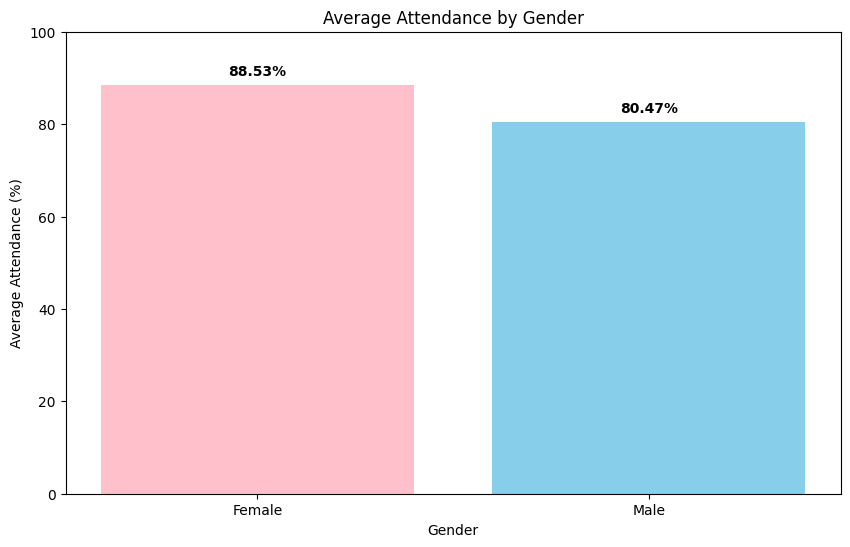

In [15]:
#=================================
# Average Attendance by Gender
#=================================

query = """
    SELECT gender, AVG(attendance_percentage) as avg_attendance
    FROM students
    GROUP BY gender
"""

attendance_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))
plt.bar(attendance_df['gender'], attendance_df['avg_attendance'], color=['pink', 'skyblue'])
plt.title('Average Attendance by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Attendance (%)')
plt.ylim(0, 100)

for i, val in enumerate(attendance_df['avg_attendance']):
    plt.text(i, val + 2, f'{val:.2f}%', ha='center', fontweight='bold')

plt.show()

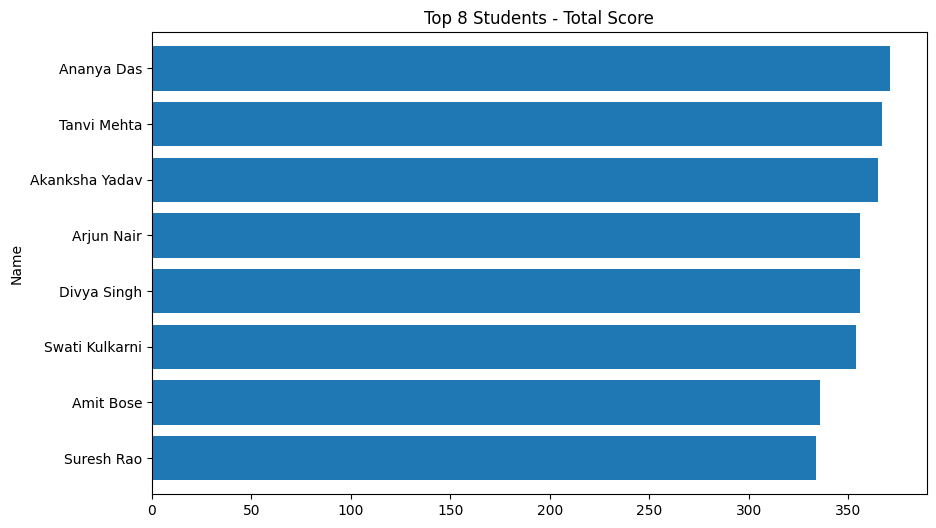

In [13]:
#========================================
# Top 8 Students - Total Score (Matplotlib)
#========================================

chart1_sql = """
     SELECT name, total_score
     FROM students
     ORDER BY total_score DESC
     LIMIT 8
"""
cursor.execute(chart1_sql)
chart1_data = cursor.fetchall()
chart1_df = pd.DataFrame(chart1_data, columns=['Name', 'Total Score'])
chart1_df['Total Score'] = pd.to_numeric(chart1_df['Total Score'])

chart1_df = chart1_df.set_index('Name')

plt.figure(figsize=(10, 6))
chart1_df['Total Score'].plot(kind='barh', title='Top 8 Students - Total Score', width=0.8)
plt.gca().invert_yaxis()
plt.show()

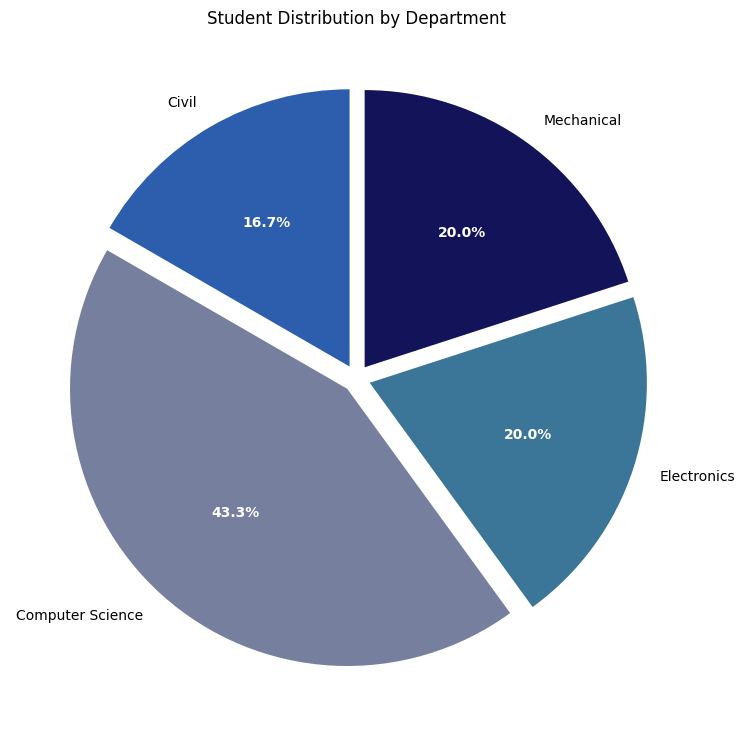

In [23]:
#================================================
# Student Distribution by Department (Pie Chart)
#================================================

chart2_sql = """
    SELECT department, COUNT(*) as student_count
    FROM students
    GROUP BY department
"""
cursor.execute(chart2_sql)
chart2_data = cursor.fetchall()
chart2_df = pd.DataFrame(chart2_data, columns=['Department', 'Student Count'])

custom_colors = ['#2C5EAD', '#767F9E', '#3B7597', '#121358']

explode = [0.05] * len(chart2_df)

plt.figure(figsize=(9, 9))
_, _, autotexts = plt.pie(
    chart2_df['Student Count'],
    labels=chart2_df['Department'],
    autopct='%1.1f%%',
    startangle=90,
    colors=custom_colors,
    explode=explode
)

for text in autotexts:
    text.set_color('white')
    text.set_weight('bold')

plt.title('Student Distribution by Department')
plt.show()

In [25]:
#================================================================
# SQL query to find average programming score for female students
#================================================================

query_female_avg = """
    SELECT AVG(programming_score) as avg_program
    FROM students
    WHERE gender = 'Female'
"""

cursor.execute(query_female_avg)
result = cursor.fetchone()[0]

print(f"Average Programming Score (Female): {result:.2f}")

Average Programming Score (Female): 70.20


In [29]:
query_avg_att = """
    SELECT department, AVG(attendance_percentage) as avg_att
    FROM students
    GROUP BY department
    HAVING avg_att > 85
"""

cursor.execute(query_avg_att)
result = cursor.fetchall()
df_results2 = pd.DataFrame(result, columns=['Department', 'Average Attendance'])
print(df_results2.to_string(index=False))

      Department  Average Attendance
Computer Science           90.692308


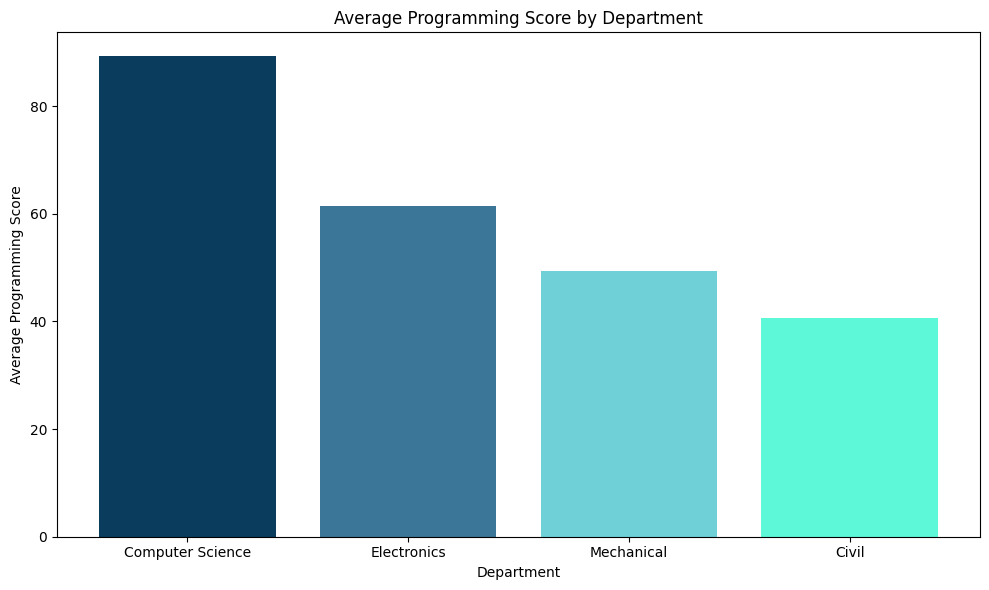

In [31]:
#================================================
#  Average PROGRAMMING scores for each Department
#================================================

chart1_sql = """
    SELECT department, ROUND(AVG(programming_score), 2) AS avg_program
    FROM students
    GROUP BY department
    ORDER BY avg_program DESC
"""
cursor.execute(chart1_sql)
chart1_data = cursor.fetchall()

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['#093C5D', '#3B7597', '#6FD1D7', '#5DF8D8']

departments = [row[0] for row in chart1_data]
avg_math_scores = [row[1] for row in chart1_data]

ax.bar(departments, avg_math_scores, color=bar_colors[0] if len(bar_colors) == 1 else bar_colors)
ax.set_xlabel('Department')
ax.set_ylabel('Average Programming Score')
ax.set_title('Average Programming Score by Department')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()